In [1]:
import pandas as pd
import commonlib.prep_export_data as prep_export_data
import commonlib.gencharts as gencharts
import matplotlib.pyplot as plt
import commonlib.config as config

In [2]:
c = config.Config()
print(c.TERRAFORM_LOG_PATH)
parsed_records=prep_export_data.read_json_from_file(c.TERRAFORM_LOG_PATH)
normalized_records=prep_export_data.normalize_records(parsed_records)
df = pd.json_normalize(normalized_records)

# df_export_start = df[df['type'] == 'export_start']
# df_export_start = df_export_start.rename(columns={'timestamp': 'start_timestamp'})

# df_export_end = df[df['type'] == 'export_end']
# df_export_end = df_export_end.rename(columns={'timestamp': 'end_timestamp'})


# df_merged_refresh = pd.merge(df_export_start[['resource_id', 
# 'start_timestamp','resource','resource_type','resource_label']],
#                              df_export_end[['resource_id', 'end_timestamp']], 
#                              on='resource_id')

# df_merged_refresh['start_datetime'] = pd.to_datetime(df_merged_refresh['start_timestamp'])
# df_merged_refresh['end_datetime'] = pd.to_datetime(df_merged_refresh['end_timestamp'])

# # calculate time difference in minutes
# df_merged_refresh['time_diff_minutes'] = (df_merged_refresh['end_datetime'] - df_merged_refresh['start_datetime']).dt.total_seconds() / 60

# --- Handle multiple exports per resource_id properly ---

# number each start and end event in order per resource_id
starts = (
    df[df["type"] == "export_start"]
    .copy()
    .sort_values(["resource_id", "timestamp"])
)
starts["start_timestamp"] = pd.to_datetime(starts["timestamp"], utc=True, errors="coerce")
starts["run"] = starts.groupby("resource_id").cumcount() + 1
starts = starts[["resource_id", "run", "start_timestamp", "resource", "resource_type", "resource_label"]]

ends = (
    df[df["type"] == "export_end"]
    .copy()
    .sort_values(["resource_id", "timestamp"])
)
ends["end_timestamp"] = pd.to_datetime(ends["timestamp"], utc=True, errors="coerce")
ends["run"] = ends.groupby("resource_id").cumcount() + 1
ends = ends[["resource_id", "run", "end_timestamp"]]

df_merged_refresh = starts.merge(ends, on=["resource_id", "run"])

df_merged_refresh["time_diff_minutes"] = (
    (df_merged_refresh["end_timestamp"] - df_merged_refresh["start_timestamp"])
    .dt.total_seconds() / 60
)


/Users/ascheble/Downloads/ciblogs/tf_json.log


##
Duration Analysis

The total number of resource type: export_start are:30


<module 'matplotlib.pyplot' from '/Users/ascheble/GitHub/scheblein/forked/cxascode-analysis-scripts/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

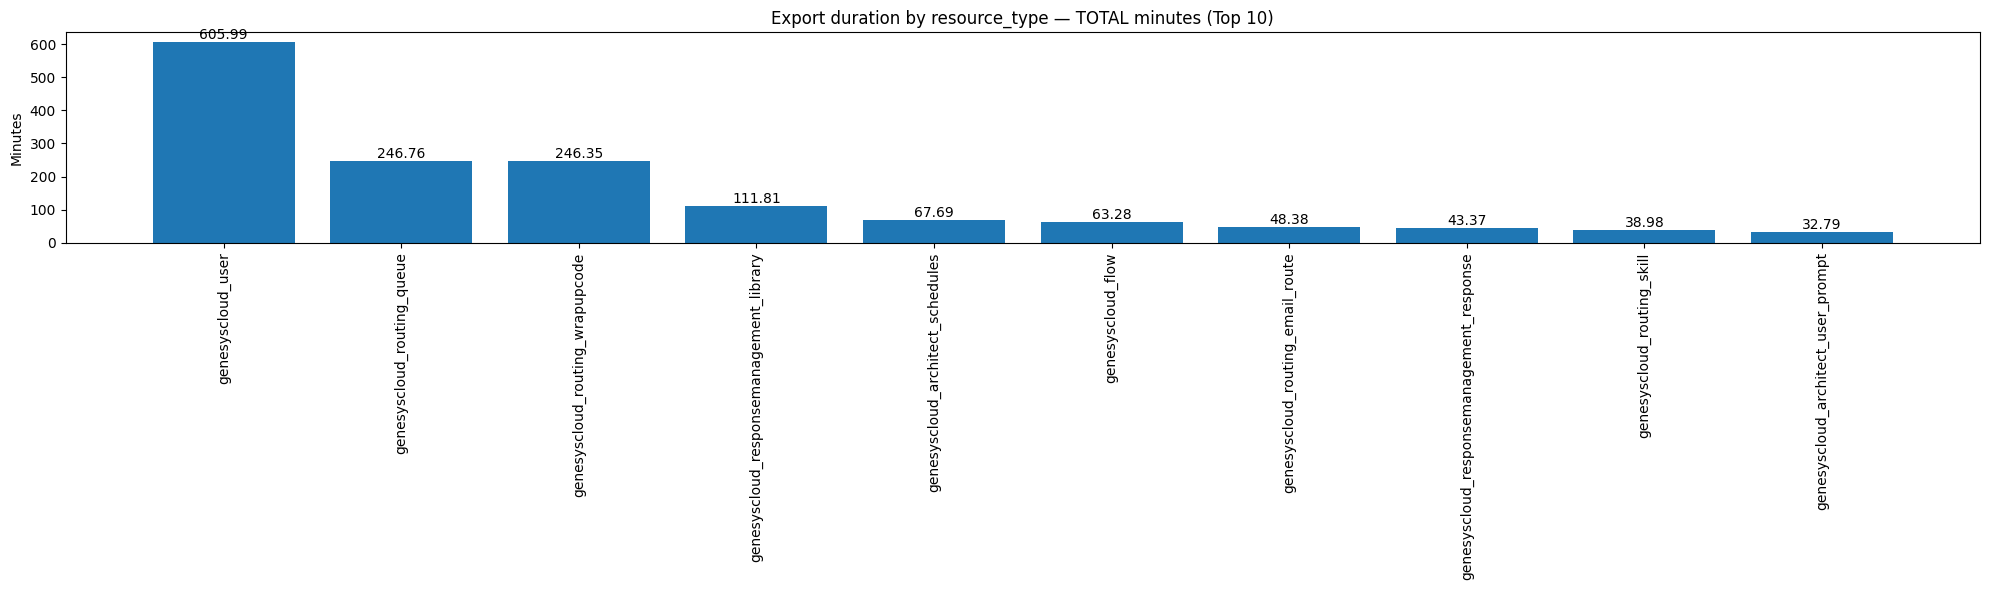

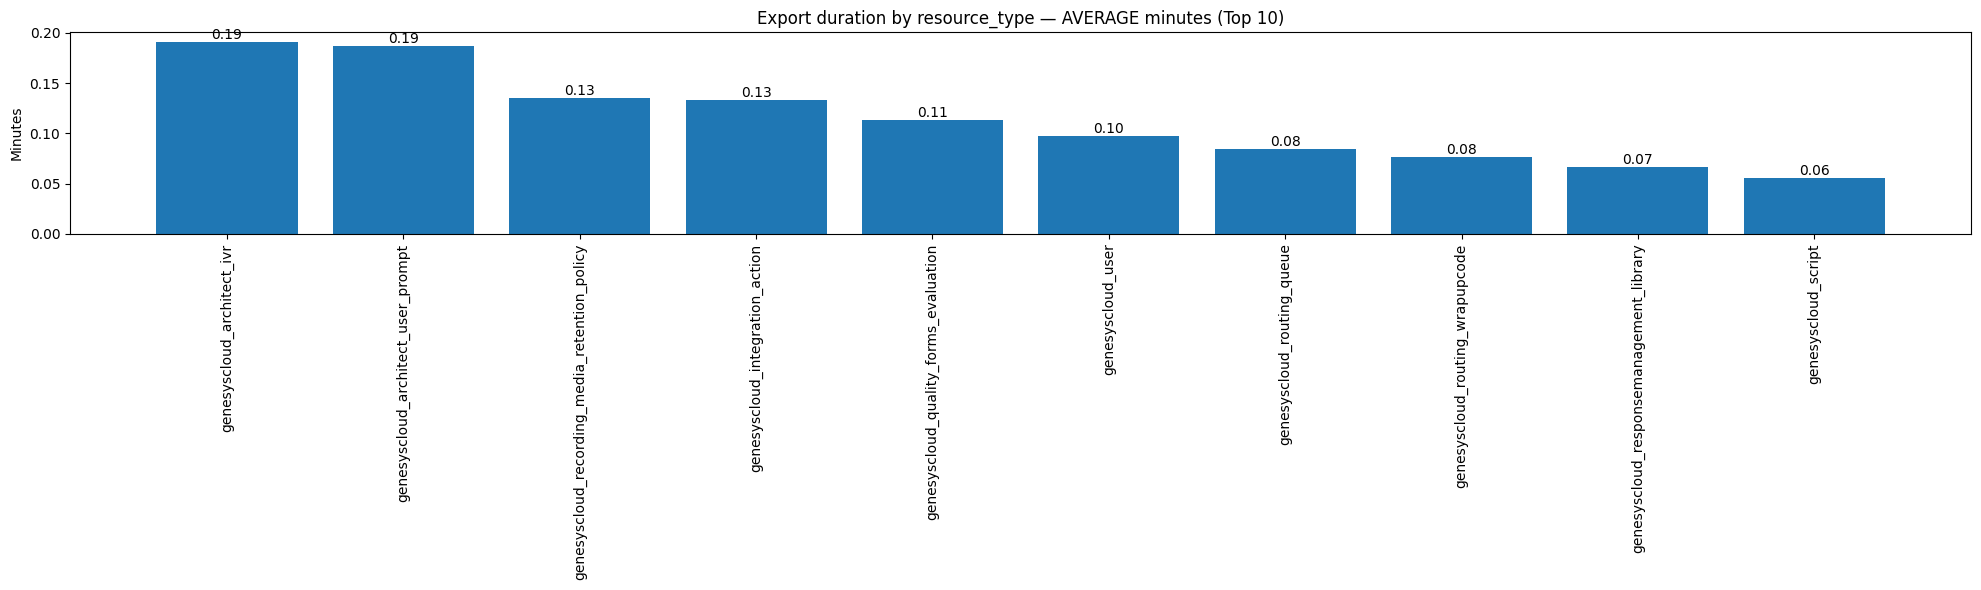

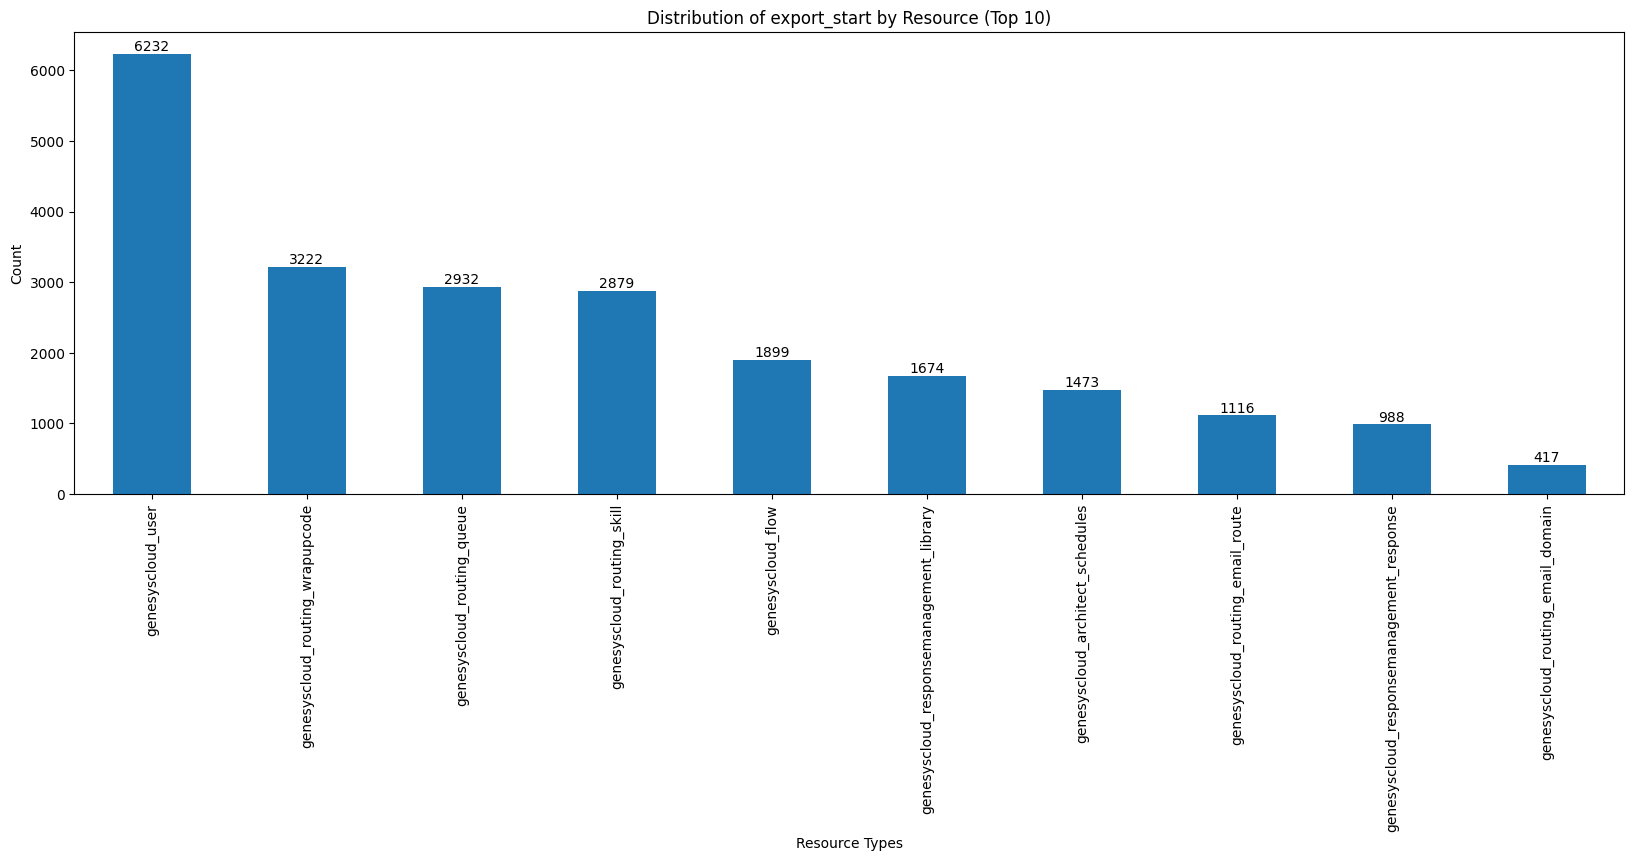

In [3]:
gencharts.generate_duration_by_resource_type(df_merged_refresh, metric="total", top_n=10)
gencharts.generate_duration_by_resource_type(df_merged_refresh, metric="average", top_n=10)
gencharts.generate_plt_by_resource_type(df,"export_start", top_n=10)

##
Longest running exports

In [4]:
df_merged_refresh[['resource', 'start_timestamp','end_timestamp','time_diff_minutes','run']].copy().sort_values(by='time_diff_minutes', ascending=False).head(20)

,resource,start_timestamp,end_timestamp,time_diff_minutes,run
9094,genesyscloud_user.ashley_viles_pnc_com,2025-10-10 14:18:06.729570+00:00,2025-10-10 14:18:55.227985+00:00,0.808307,1
21055,genesyscloud_user.linda_torango_pnc_com,2025-10-10 14:18:06.730439+00:00,2025-10-10 14:18:55.228002+00:00,0.808293,1
3799,genesyscloud_user.maricruz_romero_pnc_com,2025-10-10 14:18:06.730811+00:00,2025-10-10 14:18:55.228014+00:00,0.808287,1
19252,genesyscloud_user.caleb_huffer_pnc_com,2025-10-10 14:18:06.733689+00:00,2025-10-10 14:18:55.228099+00:00,0.808240,1
21391,genesyscloud_user.meghan_kelly565_leaserv_com,2025-10-10 14:18:06.733651+00:00,2025-10-10 14:18:55.228027+00:00,0.808240,1
22247,genesyscloud_user.alexis_creason_pnc_com,2025-10-10 14:18:06.734222+00:00,2025-10-10 14:18:55.228076+00:00,0.808231,1
22543,genesyscloud_user.allysa_mitchell_pnc_com,2025-10-10 14:18:06.734284+00:00,2025-10-10 14:18:55.228043+00:00,0.808229,1
1209,genesyscloud_user.diane_dalrymple_pnc_com,2025-10-10 14:18:06.734479+00:00,2025-10-10 14:18:55.228065+00:00,0.808226,1
12907,genesyscloud_user.courtney_edwards348_pnc_com,2025-10-10 14:18:06.734664+00:00,2025-10-10 14:18:55.228054+00:00,0.808223,1
2482,genesyscloud_user.shakirah_givens_pnc_com,2025-10-10 14:18:06.735711+00:00,2025-10-10 14:18:55.228086+00:00,0.808206,1
